# Driving PEST++ from Python

PEST++ now ships a shared library with a C ABI, so the tools can be driven from Python
instead of only run as executables. This notebook shows what that buys you.

There are two layers, the same split `pypestutils` uses:

| layer | module | what it is |
|---|---|---|
| thin | `pestpp_lib` | one method per C symbol, same names. Auditable against the header. |
| helpers | `pestpp` | classes, properties, DataFrames. What you actually use. |

This notebook uses the helper layer throughout, and dips into the thin one once to show
it is there.


## Setup

The helper layer finds the built shared library itself; set `PESTPP_LIB` to override.


In [1]:
import os, shutil, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', 'python'))
from pestpp import Ies, find_library

print('library:', find_library())


library: /Users/jwhite/Dev/pestpp/build/src/libs/pestpp_capi/pestpp-api.dylib


In [2]:
# a small ies case: the 10-parameter cross-section model that ships with the benchmarks
# Anchored ONCE, and absolute. The library chdirs into a session's working directory
# while that session is open, so a relative path evaluated later in the notebook is not
# relative to where you think it is - and one cell leaving the cwd moved turns every
# later path into a compounded one, which hides whichever cell actually broke.
HERE = os.path.abspath(os.getcwd())
BENCH = os.path.abspath(os.path.join(HERE, '..', 'benchmarks'))
os.environ['PATH'] += os.pathsep + os.path.abspath(
    os.path.join(BENCH, 'test_bin', 'mac' if sys.platform == 'darwin' else
                 ('win' if os.name == 'nt' else 'linux')))

wd = os.path.join(HERE, 'nb_ies')
if os.path.exists(wd):
    shutil.rmtree(wd)
shutil.copytree(os.path.join(BENCH, 'ies_10par_xsec', 'template'), wd)
print(wd)


/Users/jwhite/Dev/pestpp/examples/nb_ies


## 1. The short version

Open a handle, initialize, iterate. `iterations()` is a generator that stops at `noptmax`
or when the tool's own convergence test fires, whichever comes first.


In [3]:
with Ies.from_pst('pest.pst', workdir=wd, noptmax=3, ies_num_reals=20,
                  random_seed=11) as ies:
    ies.initialize()
    print(f'{ies.n_reals} realizations, starting phi {ies.phi:,.1f}')

    history = [ies.get_phi()]
    for step in ies.iterations():
        print(step)
        history.append(ies.get_phi())

    par = ies.par_df()
    obs = ies.obs_df()
    ies.finalize()

print(par.shape, obs.shape)


processing control file pest.pst
Note: 3 unused lines in pest control file, see rec file...
              starting serial run manager ...

20 realizations, starting phi 106.7
IterationStep(iter=1, n_reals=20, phi_mean=18.9383)
IterationStep(iter=2, n_reals=20, phi_mean=8.00033)
IterationStep(iter=3, n_reals=20, phi_mean=2.58377)
(20, 11) (20, 20)


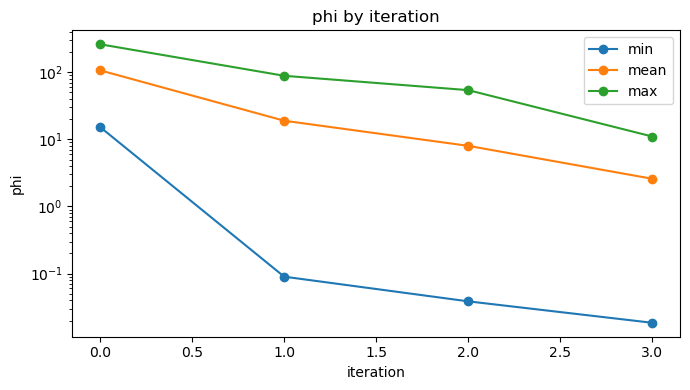

In [4]:
h = pd.DataFrame(history)
ax = h[['min', 'mean', 'max']].plot(logy=True, marker='o', figsize=(7, 4))
ax.set_xlabel('iteration'); ax.set_ylabel('phi'); ax.set_title('phi by iteration')
plt.tight_layout()


Note the options passed straight to `from_pst` -- `noptmax=3`, `ies_num_reals=20` are
the same names you would put in the control file, set programmatically instead.


## 2. Supplying your own prior ensemble

This is the part that was impossible before. `initialize()` used to draw the prior
ensemble and evaluate it in one uninterruptible call, so the realizations that got run
were always the ones PEST++ drew.

`defer_runs=True` stops just before the evaluation and hands back how many runs are
waiting. In that window the ensemble is yours to replace.


In [5]:
wd2 = os.path.join(HERE, 'nb_prior')
if os.path.exists(wd2):
    shutil.rmtree(wd2)
shutil.copytree(os.path.join(BENCH, 'ies_10par_xsec', 'template'), wd2)

with Ies.from_pst('pest.pst', workdir=wd2, noptmax=1, ies_num_reals=10,
                  random_seed=11) as ies:
    n = ies.initialize(defer_runs=True)      # nothing has run yet
    print(f'{n} runs are waiting')

    # lower=True gives pyemu-cased labels; the API takes names back in any case
    drawn = ies.par_df(lower=True)
    print('what pest++ drew:')
    display(drawn.iloc[:3, :4])

    # replace it with our own -- a deliberately tight cloud around the mean
    mine = drawn.copy()
    mine.loc[:, :] = drawn.mean(axis=0).values
    rng = np.random.default_rng(0)
    adj = [c for c in mine.columns if c.startswith('k_')]
    assert adj, 'no k_ parameters found -- check the case of par_df labels'
    mine[adj] *= rng.normal(1.0, 0.02, size=mine[adj].shape)
    ies.set_par_df(mine)

    ies.run_ensemble()                       # queue_runs + drive + process_runs
    ies.finish_initialize()

    print(f'phi of OUR ensemble: {ies.phi:,.3f}')
    used = ies.par_df(lower=True)

# the substituted values are what the tool evaluated, and they are not what it drew
print('tool used our values :', np.allclose(used[adj].values, mine[adj].values))
print('and they differ from the draw:', not np.allclose(used[adj].values, drawn[adj].values))
print(f'(compared {used[adj].size} values, not 0)')


processing control file pest.pst
Note: 3 unused lines in pest control file, see rec file...
              starting serial run manager ...

10 runs are waiting
what pest++ drew:


parnme,stage,k_01,k_02,k_03
realization,,,,
0,1.0,2.5,2.550321,2.247991
1,1.0,2.5,1.079131,7.294882
2,1.0,2.5,6.551143,1.502511


phi of OUR ensemble: 143.121
tool used our values : False
and they differ from the draw: True
(compared 100 values, not 0)


## 3. Culling realizations mid-run

Membership changes apply to every coupled ensemble at once -- parameters, observations,
noise and weights -- because keeping four containers in step by hand is a trap.


In [6]:
wd3 = os.path.join(HERE, 'nb_cull')
if os.path.exists(wd3):
    shutil.rmtree(wd3)
shutil.copytree(os.path.join(BENCH, 'ies_10par_xsec', 'template'), wd3)

with Ies.from_pst('pest.pst', workdir=wd3, noptmax=2, ies_num_reals=20,
                  random_seed=11) as ies:
    ies.initialize()
    print('before:', ies.n_reals, 'realizations, phi mean %.1f' % ies.phi)

    # drop the worst quarter by phi and keep going
    resid = (ies.obs_df() - ies.obs_df().mean(axis=0)).abs().max(axis=1)
    worst = resid.sort_values().index[-5:]
    if "BASE" in worst:
        print("not dropping base..")
        worst = worst[worst!="BASE"]
    ies.drop_realizations(worst)
    print('dropped', list(worst))
    print('after :', ies.n_reals, 'realizations')

    for step in ies.iterations():
        print(step)
        resid = (ies.obs_df() - ies.obs_df().mean(axis=0)).abs().max(axis=1)
        worst = resid.sort_values().index[-5:]
        if "BASE" in worst:
            print("not dropping base..")
            worst = worst[worst!="BASE"]
        ies.drop_realizations(worst)
        print('dropped', list(worst))
        print('after :', ies.n_reals, 'realizations')
    ies.finalize()


processing control file pest.pst
Note: 3 unused lines in pest control file, see rec file...
              starting serial run manager ...

before: 20 realizations, phi mean 106.7
not dropping base..
dropped ['9', '17', '5', '4']
after : 16 realizations
IterationStep(iter=1, n_reals=16, phi_mean=11.607)
not dropping base..
dropped ['0', '3', '11', '15']
after : 12 realizations
IterationStep(iter=2, n_reals=12, phi_mean=2.95848)
dropped ['1', '13', '12', '10', '18']
after : 7 realizations


## 4. Owning the run loop

`run_ensemble()` above is `queue()` + `run()` + `harvest()`. Splitting them lets you sit
in the middle of a batch. With a PANTHER master you can watch runs land and cancel them;
the serial run manager finishes a batch in the first slice, which `supports_live_control`
tells you up front.


In [7]:
wd4 = os.path.join(HERE, 'nb_parallel')
if os.path.exists(wd4):
    shutil.rmtree(wd4)
shutil.copytree(os.path.join(BENCH, 'ies_10par_xsec', 'template'), wd4)

seen = []

def watch(tool):
    """called after every slice of the run loop"""
    states = tool.get_run_states()
    if len(states):
        seen.append(states.status.value_counts().to_dict())

with Ies.from_pst('pest.pst', workdir=wd4, workers=3, port=4051,
                  noptmax=1, ies_num_reals=12, random_seed=11) as ies:
    print('run manager:', ies.run_manager, '| live control:', ies.supports_live_control)
    ies.initialize()

    ies.queue_runs()
    ies.run(callback=watch)
    failed = ies.process_runs()
    print('failed runs:', failed)

    display(ies.get_workers()[['index', 'host', 'state', 'avg_runtime_sec',
                               'n_completed', 'n_failed']])
    ies.finalize()

print('run states observed while the batch was in flight:')
for s in seen[:6]:
    print('  ', s)


processing control file pest.pst
Note: 3 unused lines in pest control file, see rec file...


:~-._                                                 _.-~:
: :.~^o._        ________---------________        _.o^~.:.:
 : ::.`?88booo~~~.::::::::...::::::::::::..~~oood88P'.::.:
 :  ::: `?88P .:::....         ........:::::. ?88P' :::. :
  :  :::. `? .::.            . ...........:::. P' .:::. :
   :  :::   ... ..  ...       .. .::::......::.   :::. :
   `  :' .... ..  .:::::.     . ..:::::::....:::.  `: .'
    :..    ____:::::::::.  . . ....:::::::::____  ... :
   :... `:~    ^~-:::::..  .........:::::-~^    ~::.::::
   `.::. `\   (8)  \b:::..::.:.:::::::d/  (8)   /'.::::'
    ::::.  ~-._v    |b.::::::::::::::d|    v_.-~..:::::
    `.:::::... ~~^?888b..:::::::::::d888P^~...::::::::'
     `.::::::::::....~~~ .:::::::::~~~:::::::::::::::'
      `..:::::::::::   .   ....::::    ::::::::::::,'
        `. .:::::::    .      .::::.    ::::::::'.'
          `._ .:::    .        :::::.    :::::_.'
   

,index,host,state,avg_runtime_sec,n_completed,n_failed
0,0,localhost,WAITING,1.306,8,0
1,1,localhost,WAITING,1.317,8,0
2,2,localhost,WAITING,1.315,8,0


run states observed while the batch was in flight:
   {'queued': 9, 'running': 3}
   {'queued': 9, 'running': 3}
   {'queued': 9, 'running': 3}
   {'queued': 9, 'running': 3}
   {'queued': 9, 'running': 3}
   {'queued': 9, 'running': 3}


## 4b. Owning the solve, not just the runs

Section 4 hands you the runs of a batch you asked for. This hands you the batch *itself*.

`solve(defer_runs=True)` does the linear algebra and stops: it generates the upgrade
candidates -- one per lambda x backtracking-scale combination -- and runs nothing. They are
ordinary ensembles, so you can look at them, compare them, or write to them, and what you
write is what gets run.

Then `finish_solve(defer_runs=True)` evaluates them and stops *again*, because there is a
second batch. ies tests the candidates on a SUBSET of the ensemble to pick a winning lambda
cheaply; the rest of the ensemble still has to be run at that winner. That is what
`step.pending_runs` is: loop until it comes back 0.

The result is identical to what `solve()` would have computed -- there is a test that asserts
exactly that, on the ensembles rather than on phi.

ies and mou only. `da`'s single `solve()` is a whole `noptmax` loop over a cycle, and `sqp`'s
line search proposes, runs and judges a step and may try again, so neither is one
generate -> run -> evaluate; both say so rather than approximating it.

In [8]:
wd5 = os.path.join(HERE, 'nb_defer')
if os.path.exists(wd5):
    shutil.rmtree(wd5)
shutil.copytree(os.path.join(BENCH, 'ies_10par_xsec', 'template'), wd5)

with Ies.from_pst('pest.pst', workdir=wd5, noptmax=2, ies_num_reals=8,
                  ies_subset_size=4, random_seed=11) as ies:
    ies.initialize()

    n_runs = ies.solve(defer_runs=True)
    print('candidates generated;', n_runs, 'runs implied -- none of them made yet')

    display(pd.DataFrame([{'candidate': c.index, 'lambda': c.inflation,
                           'scale': c.backtrack, 'shape': c.shape}
                          for c in ies.candidates()]))

    # a candidate is an ensemble like any other: same frames, same zero-copy views
    first = ies.candidates()[0]
    print('\ncandidate 0, first few parameter means:')
    print(first.par_df(lower=True).mean().head(3))

    # batch one: the subset, against every candidate
    ies.queue_runs()
    ies.run()
    ies.process_runs()

    step = ies.finish_solve(defer_runs=True)
    print('\nwinner picked;', step.pending_runs, 'realizations still to run at it')

    # batch two (and any after it): the rest of the ensemble at the winning lambda
    while step.pending_runs:
        ies.queue_runs()
        ies.run()
        ies.process_runs()
        step = ies.finish_solve(defer_runs=True)

    print('iteration {0} complete, phi {1:.4g}'.format(step.iter, step.phi_mean))
    ies.finalize()

processing control file pest.pst
Note: 3 unused lines in pest control file, see rec file...
              starting serial run manager ...

candidates generated; 36 runs implied -- none of them made yet


,candidate,lambda,scale,shape
0,0,1.0,0.75,"(8, 9)"
1,1,1.0,1.00,"(8, 9)"
2,2,1.0,1.10,"(8, 9)"
3,3,10.0,0.75,"(8, 9)"
4,4,10.0,1.00,"(8, 9)"
5,5,10.0,1.10,"(8, 9)"
6,6,100.0,0.75,"(8, 9)"
7,7,100.0,1.00,"(8, 9)"
8,8,100.0,1.10,"(8, 9)"



candidate 0, first few parameter means:
parnme
k_02    0.423218
k_03    0.271846
k_04    0.383313
dtype: float64

winner picked; 4 realizations still to run at it
iteration 1 complete, phi 27.33


## 4c. Watching it happen

`solve()` is silent for exactly as long as the model runs take, which on a real problem is all
of the time. `progress=True` fixes that, and works out where it is running: an updating bar in
a notebook, a rewriting line in a terminal, and whole readable lines when output is redirected
to a log.

Two details worth knowing, because both are easy to get wrong by hand:

- It writes to **stderr**, not stdout. A session opened with `quiet=True` has the library
  redirect file descriptor 1 to `pestpp.stdout.log`, and python's stdout is that same
  descriptor -- so a `print` inside a run lands in the log rather than on screen.
- `iterations(progress=True)` advances per ITERATION, because that is one blocking call into
  the library. To watch the runs *inside* an iteration, drive them yourself (section 4) or
  defer the solve (section 4b) and pass `progress=True` to `run()`.

In [9]:
from pestpp_progress import auto as progress_bar

wd6 = os.path.join(HERE, 'nb_progress')
if os.path.exists(wd6):
    shutil.rmtree(wd6)
shutil.copytree(os.path.join(BENCH, 'ies_10par_xsec', 'template'), wd6)

with Ies.from_pst('pest.pst', workdir=wd6, noptmax=3, ies_num_reals=12,
                  random_seed=11) as ies:
    ies.initialize()

    # across iterations, annotated with phi as it moves
    for step in ies.iterations(progress=True):
        pass

    print('final phi:', round(ies.phi, 4))
    ies.finalize()

processing control file pest.pst
Note: 3 unused lines in pest control file, see rec file...
              starting serial run manager ...



final phi: 6.2065


In [10]:
# and the run-level bar, driving one batch by hand
with Ies.from_pst('pest.pst', workdir=wd6, noptmax=1, ies_num_reals=12,
                  random_seed=11) as ies:
    ies.initialize(defer_runs=True)
    ies.queue_runs()
    ies.run(progress=True)        # <- counts model runs, not iterations
    ies.process_runs()
    ies.finish_initialize()
    print('prior phi:', round(ies.phi, 4))
    ies.finalize()

processing control file pest.pst
Note: 3 unused lines in pest control file, see rec file...
              starting serial run manager ...



prior phi: 95.9926


## 5. Zero-copy access

`par_df()` gives you a copy, in control-file space, with every parameter (including tied and fixed pars). When you want the tool's live buffer instead, `par_view()` hands you a numpy array pointing straight at it -- writes go through, so you modify values in place.

It is a context manager because the array is *borrowed*. It stops being yours when the block ends, and also if the ensemble reallocates underneath you (a membership change, an algorithm step). Neither is visible in the array itself -- it keeps its shape and keeps returning numbers, read from memory the tool has moved on from.

So the view is guarded rather than merely documented: use it after the block, or after a resize, and you get an `ExpiredViewError` instead of silent garbage. Take a `.copy()` inside the block if you want to keep the values.


In [ ]:
with Ies.from_pst('pest.pst', workdir=wd, noptmax=1, ies_num_reals=8,
                  random_seed=11) as ies:
    ies.initialize()

    with ies.par_view() as arr:
        print('shape       :', arr.shape)
        print('column-major:', arr.flags['F_CONTIGUOUS'], '(Eigen is)')
        print('space       :', ies.par_transform, '- adjustable parameters only and in log space for log pars')
        before = arr[0, 0]
        arr[0, 0] = before * 1.5           # this reaches C++ directly

    with ies.par_view() as arr:
        print('write persisted:', np.isclose(arr[0, 0], before * 1.5))

    ies.finalize()


## 5b. Looking at phi properly

`ies.phi` is the scalar most people want -- mean measurement phi. When you need more,
`phi_df()` gives every realization and every phi type, and `phi_summary_df()` gives the
statistics per type.

Types that are not in play for a case -- `regul` outside a regularized run, `noise` under
`ies_no_noise` -- come back as NaN rather than disappearing, so the shape of the frame
does not depend on how the control file was set up.


In [ ]:
with Ies.from_pst('pest.pst', workdir=wd, noptmax=1, ies_num_reals=10,
                  random_seed=11, ies_no_noise=False) as ies:
    ies.initialize()

    print('scalar phi (mean measurement):', round(ies.phi, 3))
    print()
    print('per realization, per type:')
    display(ies.phi_df().head())
    print('statistics per type:')
    display(ies.phi_summary_df())

    # which realizations are the worst fits?
    worst = ies.phi_df()['meas'].sort_values(ascending=False).head(3)
    print('worst three by measurement phi:')
    print(worst)
    ies.finalize()


## 6. The thin layer is right there

Anything the helpers do not wrap is one attribute away. `ies.lib` is the `pestpp_lib`
binding, whose method names match the C header one for one.


In [ ]:
with Ies.from_pst('pest.pst', workdir=wd, noptmax=0, ies_num_reals=5,
                  random_seed=11) as ies:
    print('IES_NUM_REALS      :', ies.lib.get_option('IES_NUM_REALS'))
    print('NOPTMAX            :', ies.lib.get_option('NOPTMAX'))
    print('transform status   :', ies.lib.get_par_transform_status())


## What is not here yet

Being straight about the edges, since a notebook makes them look finished:

- **`pestpp-da` runs a single cycle.** The multi-cycle driver is not exposed.
- **`mou` and `sqp` initialize atomically** -- no caller-owned initial batch, and no phi
  (mou has objectives, sqp an objective function). They do support the run loop.
- **`da` and `sqp` cannot defer a solve** (section 4b). Not an omission: `da`'s one
  iteration is a whole `noptmax` loop over a cycle, and `sqp` issues several run batches
  per iteration, so neither is one generate -> run -> evaluate.
- **No `pip install`.** The library is located in the build tree.
- **Run storage access is designed but not implemented** -- the path for handing a batch
  to your own runner and telling PEST++ when it is done.

See `docs/api_part1/` for the design notes behind all of this.
